# 11. Uczenie ze wzmocnieniem: zastosowanie modeli uczenia ze wzmocnieniem w optymalizacji procedur medycznych

In [29]:
from dataclasses import dataclass
import numpy as np

STATES =["SevereDisability", "ModerateDisability", "Independent"]
ACTIONS = ["NoRehab", "StandardRehab", "IntensiveRehab"]

S = {name: i for i, name in enumerate(STATES)}
A = {name: i for i, name in enumerate(ACTIONS)}

@dataclass
class StepResult:
    next_state: int
    reward: float
    done: bool

class SimpleMedicalEnv:
    def __init__(self, max_steps=20):
        self.max_steps = max_steps
        # Koszty akcji z Wariantu 4
        self.cost = {
            A["NoRehab"]: 0.0,
            A["StandardRehab"]: 2.0,
            A["IntensiveRehab"]: 4.0,
        }
        self.reset()

    def reset(self, start_state="SevereDisability"):
        self.state = S[start_state]
        self.t = 0
        return self.state

    def step(self, action):
        self.t += 1
        s = self.state

        # PRAWDOPODOBIEŃSTWA PRZEJŚĆ
        if s == S["SevereDisability"]:
            if action == A["NoRehab"]:
                probs = [(S["SevereDisability"], 0.75), (S["ModerateDisability"], 0.22), (S["Independent"], 0.03)]
            elif action == A["StandardRehab"]:
                probs = [(S["ModerateDisability"], 0.55), (S["SevereDisability"], 0.40), (S["Independent"], 0.05)]
            else: # IntensiveRehab
                probs = [(S["ModerateDisability"], 0.60), (S["SevereDisability"], 0.20), (S["Independent"], 0.20)]

        elif s == S["ModerateDisability"]:
            if action == A["NoRehab"]:
                probs = [(S["ModerateDisability"], 0.70), (S["Independent"], 0.20), (S["SevereDisability"], 0.10)]
            elif action == A["StandardRehab"]:
                probs = [(S["ModerateDisability"], 0.55), (S["Independent"], 0.40), (S["SevereDisability"], 0.05)]
            else: # IntensiveRehab
                probs = [(S["Independent"], 0.55), (S["ModerateDisability"], 0.40), (S["SevereDisability"], 0.05)]

        else:  # Independent
            if action == A["NoRehab"]:
                probs = [(S["Independent"], 0.85), (S["ModerateDisability"], 0.13), (S["SevereDisability"], 0.02)]
            elif action == A["StandardRehab"]:
                probs = [(S["Independent"], 0.88), (S["ModerateDisability"], 0.11), (S["SevereDisability"], 0.01)]
            else: # IntensiveRehab
                probs = [(S["Independent"], 0.90), (S["ModerateDisability"], 0.09), (S["SevereDisability"], 0.01)]

        # Wylosowanie następnego stanu
        r = np.random.rand()
        cum = 0
        next_state = s
        for ns, p in probs:
            cum += p
            if r <= cum:
                next_state = ns
                break

        # Nagrody: +10 za Independent, -5 za SevereDisability
        bonus = 0
        if next_state == S["Independent"]:
            bonus = 10
        elif next_state == S["SevereDisability"]:
            bonus = -5

        # Ostateczna nagroda to bonus minus koszt terapii
        reward = bonus - self.cost[action]

        self.state = next_state
        done = self.t >= self.max_steps
        return StepResult(next_state, reward, done)

env = SimpleMedicalEnv()

# 11. Uczenie ze wzmocnieniem (RL) w optymalizacji procedur medycznych — tutorial krok po kroku

Ten notebook pokazuje **minimalny, dydaktyczny** przykład uczenia ze wzmocnieniem
(Reinforcement Learning, RL) na uproszczzonej symulacji decyzji terapeutycznych.

⚠️ Uwaga: to **symulacja edukacyjna**, nie narzędzie kliniczne.


## Cele ćwiczenia

1. Zrozumieć elementy MDP: stan, akcja, nagroda, przejścia, współczynnik dyskontowy.
2. Zaimplementować algorytm Q-learning.
3. Wytrenować agenta i odczytać wyuczoną politykę.
4. Przeprowadzić eksperymenty (wpływ γ, ε, kosztów leczenia).


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Definicja środowiska (MDP)

Modelujemy uproszczony proces decyzyjny:
- Stany: Healthy, Stable, Critical
- Akcje: NoTreatment, Standard, Aggressive
- Nagrody: poprawa stanu zdrowia oraz koszt leczenia


In [31]:
from dataclasses import dataclass
import numpy as np

STATES = ["SevereDisability", "ModerateDisability", "Independent"]
ACTIONS =["NoRehab", "StandardRehab", "IntensiveRehab"]

S = {name: i for i, name in enumerate(STATES)}
A = {name: i for i, name in enumerate(ACTIONS)}

@dataclass
class StepResult:
    next_state: int
    reward: float
    done: bool

class SimpleMedicalEnv:
    def __init__(self, max_steps=20):
        self.max_steps = max_steps
        self.cost = {
            A["NoRehab"]: 0.0,
            A["StandardRehab"]: 2.0,
            A["IntensiveRehab"]: 4.0,
        }
        self.reset()

    def reset(self, start_state="SevereDisability"):
        self.state = S[start_state]
        self.t = 0
        return self.state

    def step(self, action):
        self.t += 1
        s = self.state

        # PRAWDOPODOBIEŃSTWA PRZEJŚĆ - WARIANT 4
        if s == S["SevereDisability"]:
            if action == A["NoRehab"]:
                probs = [(S["SevereDisability"], 0.75), (S["ModerateDisability"], 0.22), (S["Independent"], 0.03)]
            elif action == A["StandardRehab"]:
                probs = [(S["ModerateDisability"], 0.55), (S["SevereDisability"], 0.40), (S["Independent"], 0.05)]
            else: # IntensiveRehab
                probs = [(S["ModerateDisability"], 0.60), (S["SevereDisability"], 0.20), (S["Independent"], 0.20)]

        elif s == S["ModerateDisability"]:
            if action == A["NoRehab"]:
                probs = [(S["ModerateDisability"], 0.70), (S["Independent"], 0.20), (S["SevereDisability"], 0.10)]
            elif action == A["StandardRehab"]:
                probs = [(S["ModerateDisability"], 0.55), (S["Independent"], 0.40), (S["SevereDisability"], 0.05)]
            else: # IntensiveRehab
                probs = [(S["Independent"], 0.55), (S["ModerateDisability"], 0.40), (S["SevereDisability"], 0.05)]

        else:  # Independent
            if action == A["NoRehab"]:
                probs = [(S["Independent"], 0.85), (S["ModerateDisability"], 0.13), (S["SevereDisability"], 0.02)]
            elif action == A["StandardRehab"]:
                probs = [(S["Independent"], 0.88), (S["ModerateDisability"], 0.11), (S["SevereDisability"], 0.01)]
            else: # IntensiveRehab
                probs = [(S["Independent"], 0.90), (S["ModerateDisability"], 0.09), (S["SevereDisability"], 0.01)]

        # Wylosowanie następnego stanu
        r = np.random.rand()
        cum = 0
        next_state = s
        for ns, p in probs:
            cum += p
            if r <= cum:
                next_state = ns
                break

        # Nagrody: +10 za Independent, -5 za SevereDisability
        bonus = 0
        if next_state == S["Independent"]:
            bonus = 10
        elif next_state == S["SevereDisability"]:
            bonus = -5

        # Ostateczna nagroda to bonus minus koszt terapii
        reward = bonus - self.cost[action]

        self.state = next_state
        done = self.t >= self.max_steps
        return StepResult(next_state, reward, done)

env = SimpleMedicalEnv()

# --- TEST ---
state = env.reset()
for i in range(5):
    res = env.step(A["StandardRehab"])
    print(f"krok {i+1}: {STATES[state]} → {STATES[res.next_state]}, nagroda={res.reward:.2f}")
    state = res.next_state

krok 1: SevereDisability → ModerateDisability, nagroda=-2.00
krok 2: ModerateDisability → SevereDisability, nagroda=-7.00
krok 3: SevereDisability → SevereDisability, nagroda=-7.00
krok 4: SevereDisability → SevereDisability, nagroda=-7.00
krok 5: SevereDisability → ModerateDisability, nagroda=-2.00


## 2. Algorytm Q-learning

Aktualizacja:
Q(s,a) ← Q(s,a) + α [ r + γ max Q(s′,a′) − Q(s,a) ]

Stosujemy strategię eksploracji ε-greedy.


In [32]:
def epsilon_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[s])

def q_learning(env, episodes=2000, alpha=0.1, gamma=0.95, epsilon=0.3):
    Q = np.zeros((len(STATES), len(ACTIONS)))
    rewards = []

    for ep in range(episodes):
        s = env.reset()
        total = 0
        while True:
            a = epsilon_greedy(Q, s, epsilon)
            res = env.step(a)
            Q[s, a] += alpha * (res.reward + gamma * np.max(Q[res.next_state]) - Q[s, a])
            total += res.reward
            s = res.next_state
            if res.done:
                break
        rewards.append(total)

    return Q, rewards

Q, rewards = q_learning(env)


## 3. Odczyt polityki decyzyjnej


In [33]:
policy = {STATES[s]: ACTIONS[np.argmax(Q[s])] for s in range(len(STATES))}
policy


{'SevereDisability': 'IntensiveRehab',
 'ModerateDisability': 'IntensiveRehab',
 'Independent': 'NoRehab'}

In [34]:
pd.DataFrame(Q, index=STATES, columns=ACTIONS)


,NoRehab,StandardRehab,IntensiveRehab
SevereDisability,107.456764,113.462360,119.794490
ModerateDisability,121.350720,124.931096,128.429645
Independent,137.521499,136.913928,135.745452


## 4. Krzywa uczenia


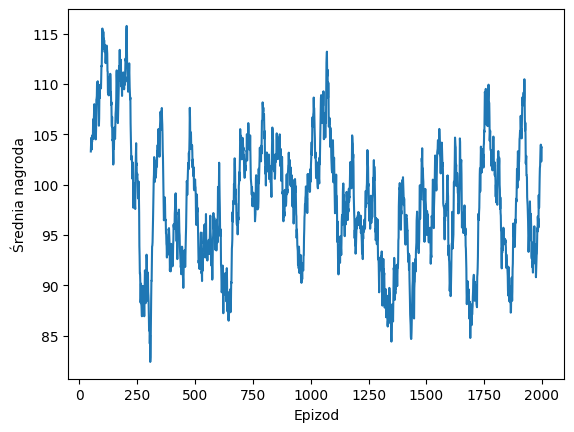

In [35]:
plt.plot(pd.Series(rewards).rolling(50).mean())
plt.xlabel("Epizod")
plt.ylabel("Średnia nagroda")
plt.show()


## 5. Symulacja działania wyuczonej polityki


In [36]:
state = env.reset()
trajectory = []

while True:
    action = np.argmax(Q[state])
    res = env.step(action)
    trajectory.append((STATES[state], ACTIONS[action], STATES[res.next_state], res.reward))
    state = res.next_state
    if res.done:
        break

pd.DataFrame(trajectory, columns=["state", "action", "next_state", "reward"])


,state,action,next_state,reward
0,SevereDisability,IntensiveRehab,ModerateDisability,-4.0
1,ModerateDisability,IntensiveRehab,Independent,6.0
2,Independent,NoRehab,Independent,10.0
3,Independent,NoRehab,Independent,10.0
4,Independent,NoRehab,Independent,10.0
5,Independent,NoRehab,Independent,10.0
6,Independent,NoRehab,Independent,10.0
7,Independent,NoRehab,Independent,10.0
8,Independent,NoRehab,Independent,10.0
9,Independent,NoRehab,Independent,10.0


## 6. Pytania kontrolne

1. Dlaczego leczenie agresywne jest preferowane w stanie krytycznym?
2. Jak zmieni się polityka po zwiększeniu kosztu leczenia?
3. Jaką rolę pełni współczynnik γ?
4. Dlaczego RL w medycynie musi być stosowane wyłącznie w symulacjach?


# 8. Deep Reinforcement Learning (DQN) — wersja TensorFlow/Keras

W DQN aproksymujemy funkcję Q(s,a) siecią neuronową:
Q(s,a; θ) ≈ Q*(s,a)

Aby stabilizować uczenie stosujemy:
- **Replay Buffer** (uczenie na losowych mini-batchach z pamięci)
- **Target Network** (oddzielna sieć do wyznaczania celu TD)


In [37]:
# Jeśli TensorFlow nie jest zainstalowany:
# !pip install tensorflow


In [38]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import deque
import random
import matplotlib.pyplot as plt


## 8.1 Kodowanie stanu (one-hot)

Stany kliniczne kodujemy jako wektory one-hot:
- Healthy  → [1, 0, 0]
- Stable   → [0, 1, 0]
- Critical → [0, 0, 1]


In [39]:
def encode_state(state_idx, n_states):
    v = np.zeros(n_states, dtype=np.float32)
    v[state_idx] = 1.0
    return v


## 8.2 Replay Buffer


In [40]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return s.astype(np.float32), a.astype(np.int32), r.astype(np.float32), s2.astype(np.float32), d.astype(np.float32)

    def __len__(self):
        return len(self.buffer)


## 8.3 Model Q (sieć neuronowa Keras)


In [41]:
def build_q_network(state_dim, action_dim):
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(action_dim)  # wartości Q dla każdej akcji
    ])
    return model


## 8.4 Funkcje pomocnicze: wybór akcji i aktualizacja target network


In [42]:
def epsilon_greedy_action(q_model, state_vec, epsilon, action_dim):
    if np.random.rand() < epsilon:
        return np.random.randint(action_dim)
    q = q_model(np.expand_dims(state_vec, axis=0), training=False).numpy()[0]
    return int(np.argmax(q))

def update_target_network(q_model, target_model):
    target_model.set_weights(q_model.get_weights())


## 8.5 Trening DQN (z target network)

Cel TD z target network:
y = r + γ * max_a' Q_target(s', a')  (jeśli done=0)
y = r                               (jeśli done=1)


In [43]:
# Zakładamy, że masz już zdefiniowane: STATES, ACTIONS, env = SimpleMedicalEnv(...)
n_states = len(STATES)
n_actions = len(ACTIONS)

env = SimpleMedicalEnv(max_steps=20)

q_model = build_q_network(state_dim=n_states, action_dim=n_actions)
target_model = build_q_network(state_dim=n_states, action_dim=n_actions)
update_target_network(q_model, target_model)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = keras.losses.Huber()  # stabilniejsza niż MSE

buffer = ReplayBuffer(capacity=10000)

gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

batch_size = 64
episodes = 1200
warmup_steps = 200   # zanim zaczniemy trenować, zbierz trochę doświadczeń
target_update_freq = 50  # co ile epizodów kopiować wagi do target network

episode_rewards = []
loss_history = []

@tf.function
def train_step(states_b, actions_b, rewards_b, next_states_b, dones_b):
    # target: r + gamma * max_a Q_target(s', a') * (1-done)
    next_q = target_model(next_states_b, training=False)
    max_next_q = tf.reduce_max(next_q, axis=1)
    targets = rewards_b + gamma * max_next_q * (1.0 - dones_b)

    with tf.GradientTape() as tape:
        q_values = q_model(states_b, training=True)
        idx = tf.stack([tf.range(tf.shape(actions_b)[0]), actions_b], axis=1)
        q_sa = tf.gather_nd(q_values, idx)
        loss = loss_fn(targets, q_sa)

    grads = tape.gradient(loss, q_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, q_model.trainable_variables))
    return loss

# --- trening ---
step_count = 0
for ep in range(episodes):
    s = env.reset(start_state="SevereDisability") # <--- TUTAJ ZMIANA
    s_vec = encode_state(s, n_states)
    total_reward = 0.0

    while True:
        a = epsilon_greedy_action(q_model, s_vec, epsilon, n_actions)
        res = env.step(a)

        s2_vec = encode_state(res.next_state, n_states)
        buffer.push(s_vec, a, res.reward, s2_vec, float(res.done))
        step_count += 1

        s_vec = s2_vec
        total_reward += res.reward

        # trening po rozgrzewce i gdy mamy batch
        if step_count > warmup_steps and len(buffer) >= batch_size:
            sb, ab, rb, s2b, db = buffer.sample(batch_size)
            loss = train_step(
                tf.convert_to_tensor(sb),
                tf.convert_to_tensor(ab),
                tf.convert_to_tensor(rb),
                tf.convert_to_tensor(s2b),
                tf.convert_to_tensor(db),
            )
            loss_history.append(float(loss.numpy()))

        if res.done:
            break

    # epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # aktualizacja target network
    if (ep + 1) % target_update_freq == 0:
        update_target_network(q_model, target_model)

    episode_rewards.append(total_reward)

    if (ep + 1) % 100 == 0:
        print(f"Epizod {ep+1}/{episodes} | reward={total_reward:.2f} | epsilon={epsilon:.3f} | buffer={len(buffer)}")


Epizod 100/1200 | reward=47.00 | epsilon=0.606 | buffer=2000
Epizod 200/1200 | reward=115.00 | epsilon=0.367 | buffer=4000
Epizod 300/1200 | reward=156.00 | epsilon=0.222 | buffer=6000
Epizod 400/1200 | reward=140.00 | epsilon=0.135 | buffer=8000
Epizod 500/1200 | reward=95.00 | epsilon=0.082 | buffer=10000
Epizod 600/1200 | reward=71.00 | epsilon=0.050 | buffer=10000
Epizod 700/1200 | reward=107.00 | epsilon=0.050 | buffer=10000
Epizod 800/1200 | reward=115.00 | epsilon=0.050 | buffer=10000
Epizod 900/1200 | reward=165.00 | epsilon=0.050 | buffer=10000
Epizod 1000/1200 | reward=170.00 | epsilon=0.050 | buffer=10000
Epizod 1100/1200 | reward=156.00 | epsilon=0.050 | buffer=10000
Epizod 1200/1200 | reward=43.00 | epsilon=0.050 | buffer=10000


## 8.6 Krzywa uczenia DQN (TensorFlow)


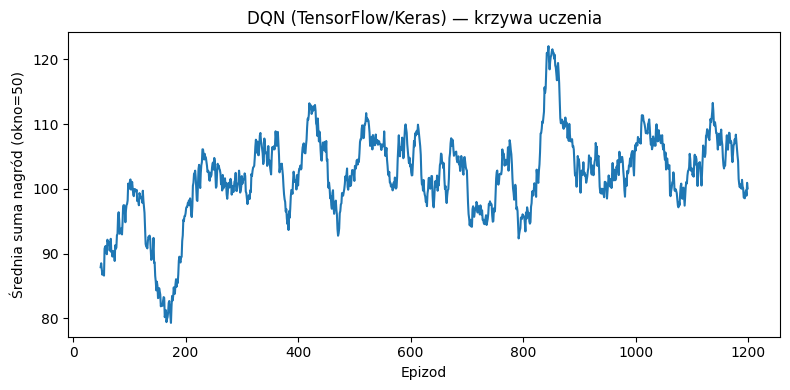

In [44]:
plt.figure(figsize=(8,4))
plt.plot(pd.Series(episode_rewards).rolling(50).mean())
plt.xlabel("Epizod")
plt.ylabel("Średnia suma nagród (okno=50)")
plt.title("DQN (TensorFlow/Keras) — krzywa uczenia")
plt.tight_layout()
plt.show()


## 8.7 Odczyt polityki z wyuczonego DQN

Dla każdego stanu wybieramy akcję o największej wartości Q.


In [45]:
def dqn_policy_tf(q_model):
    pol = {}
    for i, s_name in enumerate(STATES):
        v = encode_state(i, n_states)
        q = q_model(np.expand_dims(v, axis=0), training=False).numpy()[0]
        pol[s_name] = ACTIONS[int(np.argmax(q))]
    return pol

dqn_policy_tf(q_model)


{'SevereDisability': 'StandardRehab',
 'ModerateDisability': 'IntensiveRehab',
 'Independent': 'NoRehab'}

## 8.8 Krótka interpretacja

- DQN uczy się strategii **sekwencyjnej**: akcja jest optymalna w sensie sumy nagród.
- Target network stabilizuje uczenie (cele TD nie „uciekają”).
- Replay buffer redukuje korelację próbek.

W medycynie RL/DQN:
- wymaga symulatorów lub uczenia offline (z danych),
- nie może być używane autonomicznie bez walidacji klinicznej,
- trzeba kontrolować bezpieczeństwo (reward hacking, bias, niepewność).


## 8.9 Zadania rozszerzające

1. Zwiększ liczbę stanów (np. VeryCritical) i zmodyfikuj przejścia.
2. Zwiększ koszt terapii agresywnej i sprawdź zmianę polityki.
3. Porównaj DQN vs tablicowy Q-learning (polityka + średnia nagroda).
4. Zmień funkcję nagrody: dodaj karę za częste leczenie agresywne.
5. Dodaj „stan” złożony (np. one-hot + dodatkowa cecha ciągła) i dostosuj sieć.


# 9. Explainable Reinforcement Learning (XRL)

Uczenie ze wzmocnieniem, a szczególnie Deep Reinforcement Learning (DQN),
często jest krytykowane za brak interpretowalności („czarna skrzynka”).

W medycynie **wyjaśnialność decyzji** jest kluczowa, ponieważ:
- decyzje wpływają na zdrowie i życie pacjenta,
- lekarz musi rozumieć *dlaczego* system rekomenduje daną akcję,
- wymagane są audytowalność i zgodność etyczna.

W tej sekcji pokazujemy **proste, dydaktyczne metody wyjaśniania decyzji DQN**.


## 9.1 Co można wyjaśniać w RL?

W RL nie wyjaśniamy „klasy” jak w klasyfikacji, lecz:
- **wybór akcji** w danym stanie,
- **wartości Q(s,a)** dla wszystkich możliwych akcji,
- **alternatywne decyzje**, które agent *mógł* podjąć,
- wpływ parametrów nagrody na strategię.

W naszym przypadku:
- stan = stan kliniczny pacjenta,
- akcja = decyzja terapeutyczna.


## 9.2 Wyjaśnienie typu: „dlaczego ta akcja?”

Najprostsze i bardzo skuteczne wyjaśnienie polega na:
1. obliczeniu wartości Q dla wszystkich akcji,
2. pokazaniu, że wybrana akcja ma najwyższą wartość oczekiwaną.


In [46]:
def explain_action(q_model, state_idx):
    state_vec = encode_state(state_idx, n_states)
    q_values = q_model(np.expand_dims(state_vec, axis=0), training=False).numpy()[0]

    explanation = pd.DataFrame({
        "akcja": ACTIONS,
        "Q(s,a)": q_values
    }).sort_values("Q(s,a)", ascending=False)

    return explanation


In [47]:
state_name = "SevereDisability"
state_idx = STATES.index(state_name)

explain_action(q_model, state_idx)


,akcja,"Q(s,a)"
1,StandardRehab,120.884781
2,IntensiveRehab,120.883987
0,NoRehab,105.693764


### Interpretacja kliniczna

Przykładowe wyjaśnienie:
- Agent wybrał akcję **Aggressive**, ponieważ jej wartość Q(s,a) jest najwyższa.
- Oznacza to, że w długim horyzoncie czasowym ta decyzja:
  - maksymalizuje poprawę stanu,
  - minimalizuje ryzyko pogorszenia,
  - uwzględnia koszt terapii.

Takie wyjaśnienie można przedstawić lekarzowi w formie tabeli lub wykresu.


## 9.3 Wyjaśnienie kontrfaktyczne: „co by było, gdyby…?”

Wyjaśnienie kontrfaktyczne odpowiada na pytanie:
> „Co by się stało, gdyby agent wybrał inną akcję?”

Porównujemy wartości Q dla alternatywnych decyzji.


In [48]:
def counterfactual_explanation(q_model, state_idx):
    df = explain_action(q_model, state_idx)
    best = df.iloc[0]
    second = df.iloc[1]

    diff = best["Q(s,a)"] - second["Q(s,a)"]

    return {
        "najlepsza_akcja": best["akcja"],
        "alternatywa": second["akcja"],
        "roznica_Q": float(diff)
    }


In [49]:
counterfactual_explanation(q_model, state_idx)


{'najlepsza_akcja': 'StandardRehab',
 'alternatywa': 'IntensiveRehab',
 'roznica_Q': 0.00079345703125}

## 9.4 Wrażliwość decyzji na zmianę nagrody (Explainability globalna)

W RL decyzje są silnie zależne od funkcji nagrody.
Możemy badać:
- jak zmiana kosztów terapii wpływa na politykę,
- czy model preferuje agresywne leczenie zbyt często.


In [50]:
def evaluate_policy_under_cost(intensive_cost):
    env_tmp = SimpleMedicalEnv(max_steps=20)
    env_tmp.cost[A["IntensiveRehab"]] = intensive_cost

    q_tmp = build_q_network(n_states, n_actions)
    target_tmp = build_q_network(n_states, n_actions)
    update_target_network(q_tmp, target_tmp)

    # krótki trening
    buffer_tmp = ReplayBuffer()
    optimizer_tmp = keras.optimizers.Adam(1e-3)

    for _ in range(300):
        s = env_tmp.reset()
        s_vec = encode_state(s, n_states)
        while True:
            a = epsilon_greedy_action(q_tmp, s_vec, 0.2, n_actions)
            res = env_tmp.step(a)
            s2_vec = encode_state(res.next_state, n_states)
            buffer_tmp.push(s_vec, a, res.reward, s2_vec, float(res.done))
            s_vec = s2_vec
            if res.done:
                break

    return dqn_policy_tf(q_tmp)

## 9.5 Podsumowanie Explainable RL

Zastosowane metody wyjaśniania:
- ✔ analiza wartości Q(s,a),
- ✔ porównania kontrfaktyczne,
- ✔ analiza wrażliwości na nagrodę.

Są to metody:
- proste,
- zrozumiałe dla lekarzy,
- zgodne z ideą „human-in-the-loop”.

W praktyce klinicznej Explainable RL:
- nie zastępuje lekarza,
- wspiera decyzje,
- zwiększa zaufanie do systemu AI.


## 9.6 Zadania dla studentów (Explainable RL)

1. Zaprojektuj komunikat tekstowy „dlaczego wybrano tę akcję”.
2. Dodaj próg niepewności decyzji (na podstawie różnicy Q).
3. Porównaj wyjaśnienia dla stanu Stable i Critical.
4. Zaproponuj wizualizację Q(s,a) (wykres słupkowy).
5. Opisz ograniczenia Explainable RL w medycynie.
